# 0.0. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import inflection
import math
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
from IPython.display import Image



## 0.1 Help functions

## 0.2 Loading data

In [2]:
df_sales_raw = pd.read_csv("../data/raw/train.csv", low_memory=False)
df_store_raw = pd.read_csv("../data/raw/store.csv", low_memory=False)

# merge
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')


In [3]:
df_raw.sample()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
379311,970,5,2014-08-01,3958,420,1,1,0,1,a,a,910.0,12.0,2014.0,1,37.0,2009.0,"Jan,Apr,Jul,Oct"


In [4]:
df1 = df_raw.copy()

# 1.0 Step 1 - DESCRIPTION DATAS

## 1.1 Rename Columns

In [5]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

snake_case = lambda x: inflection.underscore( x )

cols_new = list( map( snake_case, cols_old) )

#rename
df1.columns = cols_new

## 1.2 Data Daimensions

In [6]:
print('number of rown {}'.format(df1.shape[0]))
print('number of columns {}'.format(df1.shape[1]))

number of rown 1017209
number of columns 18


## 1.3 Data Types

In [7]:
df1.dtypes

store                             int64
day_of_week                       int64
date                             object
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                    object
school_holiday                    int64
store_type                       object
assortment                       object
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                   object
dtype: object

In [8]:
# change the date column

df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

## 1.4 Check NA

In [9]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

## 1.5 Fullout Na

In [10]:
df1['competition_distance'].max()

np.float64(75860.0)

In [11]:
## competition_distance
df1['competition_distance'] = df1['competition_distance'].apply(lambda x : 200000.0 if math.isnan(x) else x)

## competition_open_since_month
df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

## competition_open_since_year
df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

## promo2_since_week
df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

## promo2_since_year
df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

## promo_interval
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Set', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# if promo_interval is na
df1['promo_interval'] = df1['promo_interval'].fillna(0)

# create a column map_month
df1['month_map'] = df1['date'].dt.month.map(month_map)

# 
df1['is_promo'] = df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 
                    else 1 if x['month_map'] in str(x['promo_interval']).split(',') else 0, axis=1)


In [12]:
df1.sample(7).T

,310446,572531,262812,377210,83262,306747,267893
store,247,207,309,697,753,297,791
day_of_week,1,1,3,7,1,5,5
date,2014-10-13 00:00:00,2014-02-03 00:00:00,2014-12-03 00:00:00,2014-08-03 00:00:00,2015-05-18 00:00:00,2014-10-17 00:00:00,2014-11-28 00:00:00
sales,6190,20159,8216,0,11514,5476,11821
customers,608,1914,646,0,946,657,1107
open,1,1,1,0,1,1,1
promo,0,1,1,0,1,0,1
state_holiday,0,0,0,0,0,0,0
school_holiday,0,0,0,0,0,0,0
store_type,d,a,d,d,d,a,a


In [13]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

In [14]:
# cópia do df1 modificado
df2 = df1.copy()

## 1.6 Change Type

In [15]:
# analyrics datas after changes
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
month_map                               object
is_promo                                 int64
dtype: object

In [16]:
df2['competition_open_since_month'] = df2['competition_open_since_month'].astype( int )
df2['competition_open_since_year'] = df2['competition_open_since_year'].astype( int )
df2['promo2_since_week'] = df2['promo2_since_week'].astype( int )
df2['promo2_since_year'] = df2['promo2_since_year'].astype(int)


In [17]:
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[ns]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                           object
school_holiday                           int64
store_type                              object
assortment                              object
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                          object
month_map                               object
is_promo                                 int64
dtype: object

## 1.7 Descriptive Statistical

### 1.7.1 Numerical Attributes

In [18]:
num_attributes = df2.select_dtypes(include = ['int64','float64'])
cat_attributes = df2.select_dtypes(exclude = ['int64','float64', 'datetime64[ns]'])


In [19]:
## central tendence
# mean
ct1 = pd.DataFrame(num_attributes.apply( np.mean )).T

# median
ct2 = pd.DataFrame(num_attributes.apply( np.median )).T

## dispersion
# std
d1 = pd.DataFrame(num_attributes.apply( np.std )).T

# min
d2 = pd.DataFrame(num_attributes.apply( np.min )).T

# max
d3 = pd.DataFrame(num_attributes.apply( np.max )).T

# range
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min() )).T

# skew
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew() )).T

# Kurtosis
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis() )).T

# concatenate
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis',]
m



,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


### 1.7.2 Categorical Attributes

In [20]:
# how many nivel each category vaiable has
cat_attributes.apply(lambda x: x.unique().shape[0])


state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

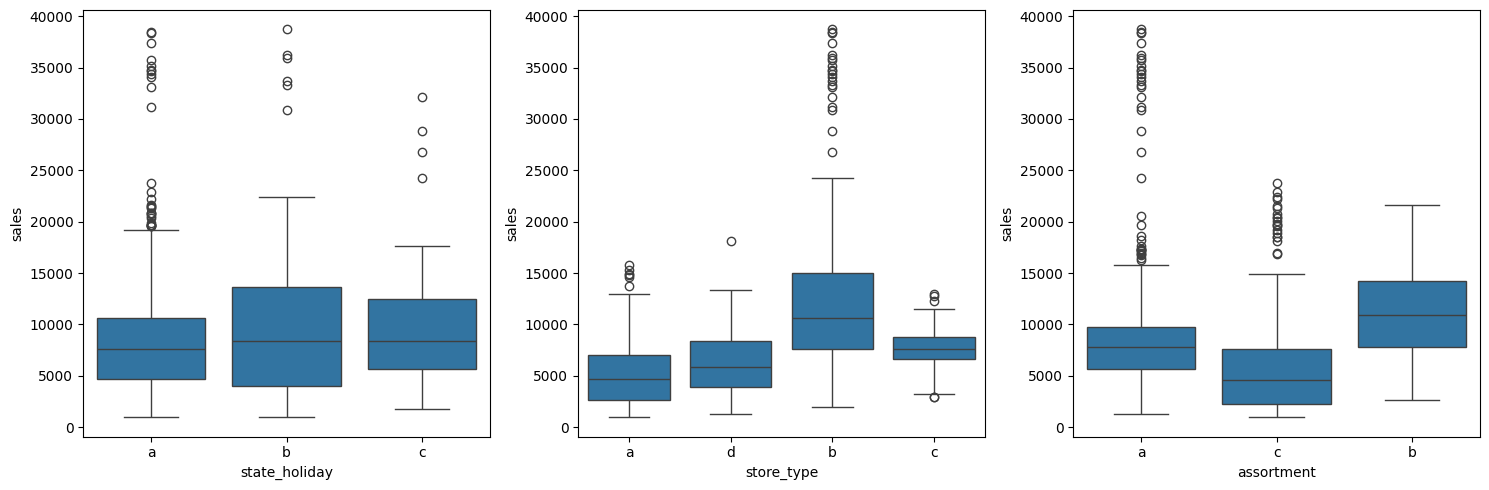

In [21]:
# filter the sales > 0 and stores dosen't open in holyday
aux1 = df2[(df2['state_holiday'] != '0' ) & (df2['sales'] > 0)]

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.tight_layout() 
plt.show()


# 2.0 Step 2 - FEATURE ENGINNERING

In [22]:
df3 = df2.copy()

## 2.1 Mind Map Hypoteses

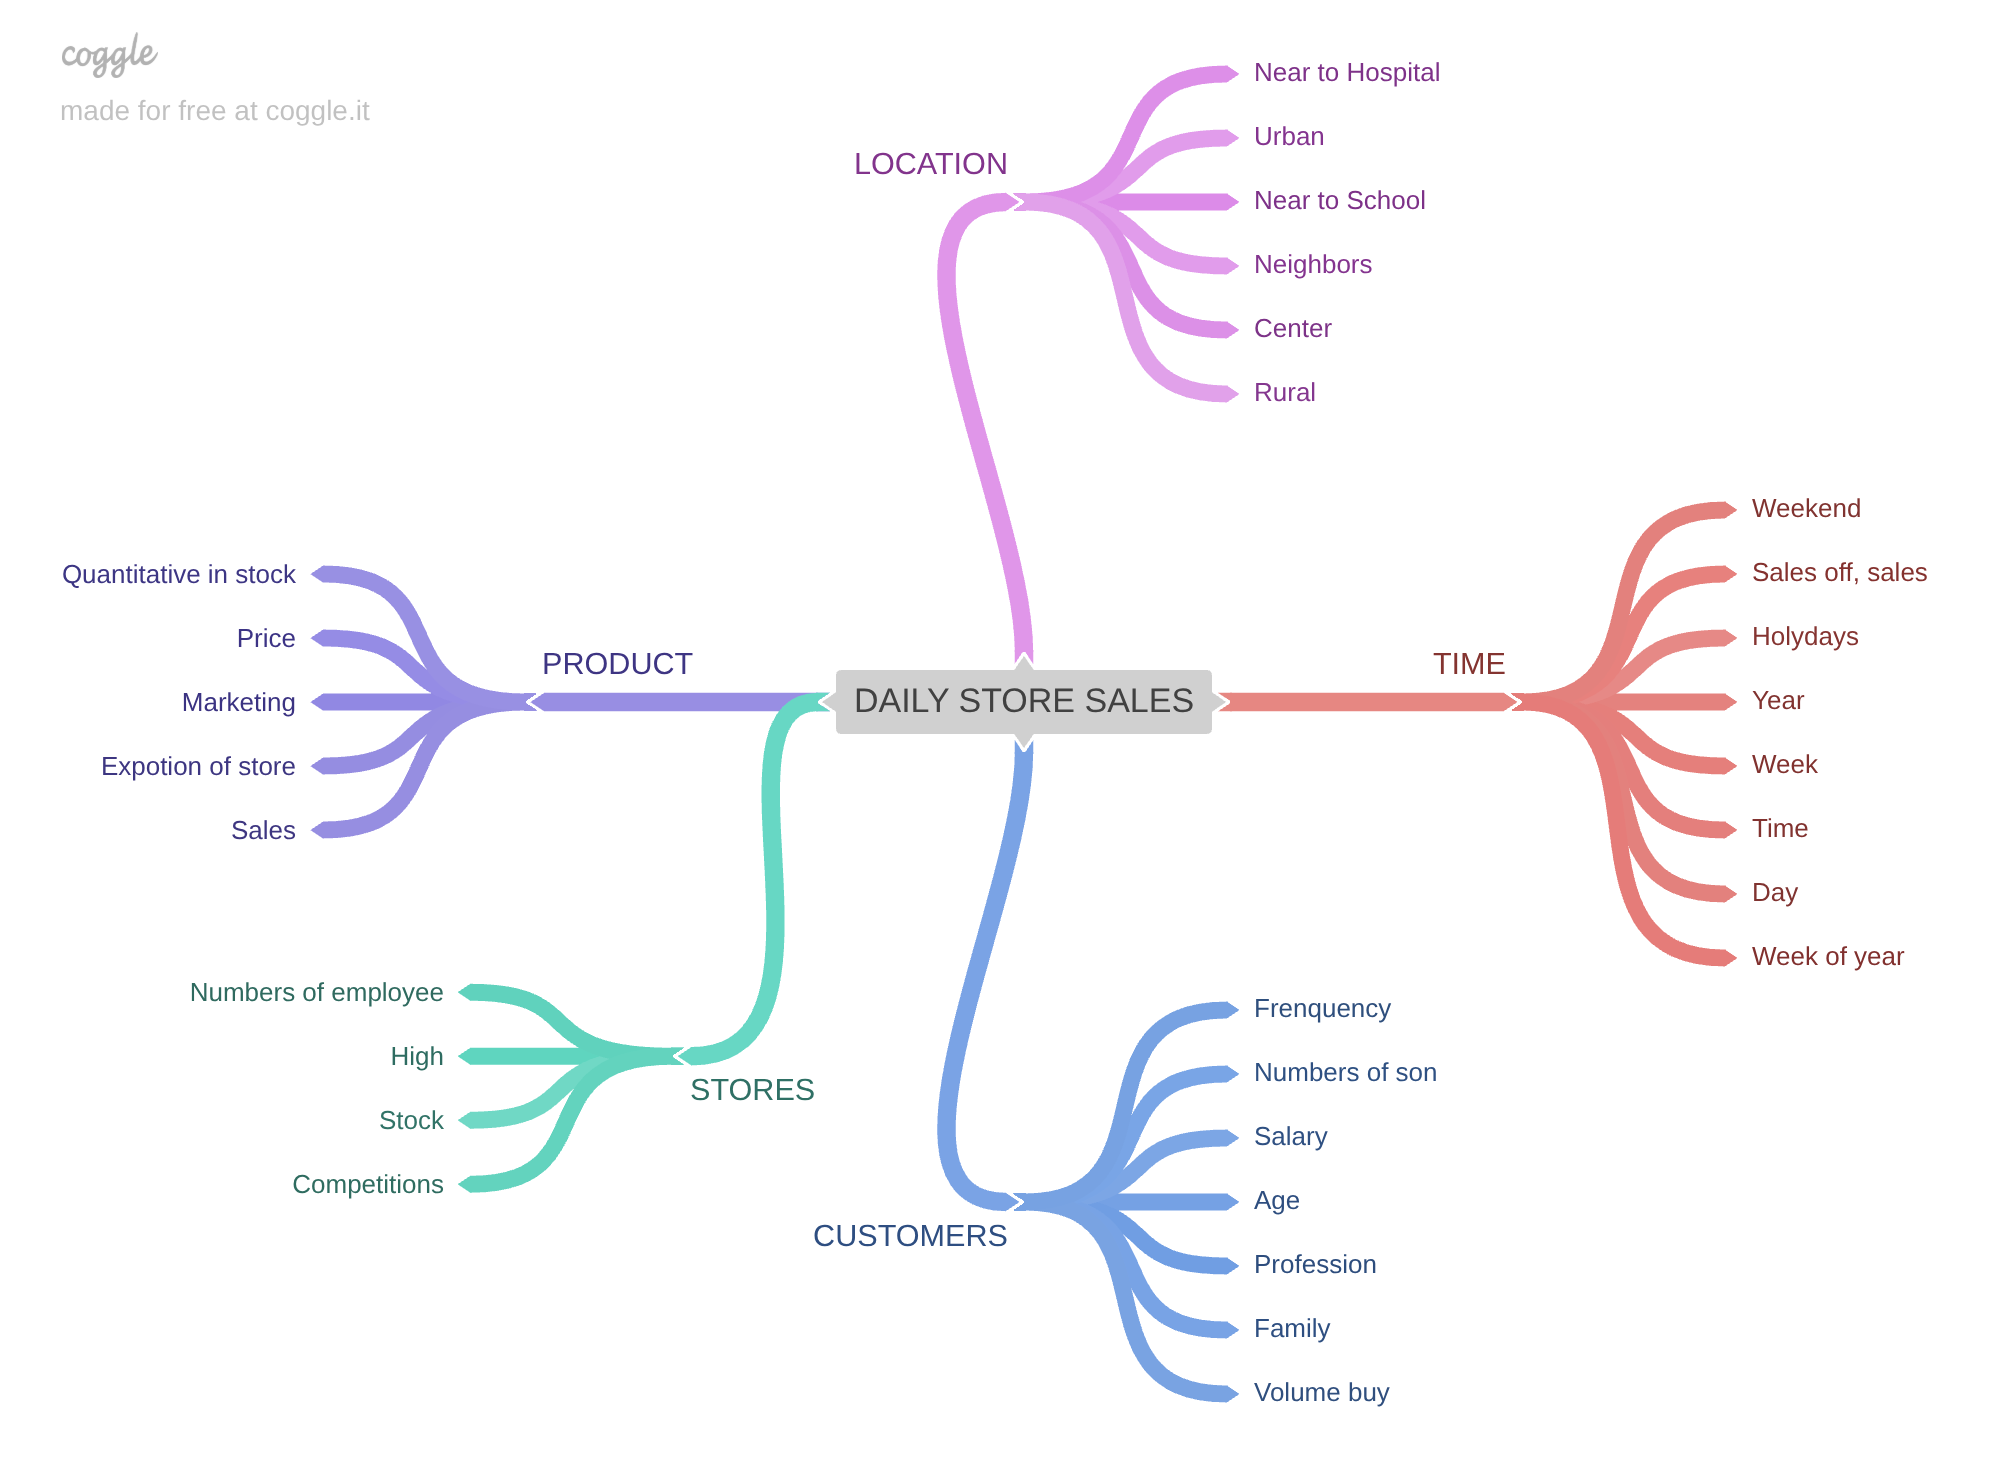

In [23]:
Image('../img/MindMapHypoteses.png')

## 2.2 Hypoteses

### 2.2.1 Stores of hypoteses

**1.** Lojas com maior número de funcionários vendem mais. - sem dados

**2.** Lojas com maior capacidade de estoque vendem mais. - sem dados

**3.** Lojas com maior porte vedem mais. - sem dados

**4.** Lojas com maior sortimento vendem mais.

**5.** Lojas com competidores mais próximos vendem menos.

**6.** Lojas com competidores à mais tempo vendem mais.



### 2.2.2 Products of hypoteses

**1.** Lojas que investem mais em Marketing vendem mais. - sem dados

**2.** Lojas que expoem mais produtos vendem mais. - sem dados

**3.** Lojas com produtos com menores preços vendem mais. - sem dados

**4.** Lojas com promoções mais (agressivas) vendem mais. -sem dados

**5.** Lojas com promoções ativas por mais tempo vendem mais. - sem dados

**6.** Lojas com mais dias de promoção vendem mais.

**7.** Lojas com mais promoções consecutivas vendem mais.

### 2.2.3 Time of hypoteses

**1.** Lojas abertas durante o feriado de Natal vendem mais.

**2.** Lojas vendem mais ao longo dos anos.

**3.** Lojas vendem mais no segundo semestre do ano.

**4.** Lojas vendem mais depois do dia 10 de cada mês.

**5.** Lojas vendem menos aos fins de semana.

**6.** Lojas vendem menos nos feriados escolares.

## 2.3 List of Hypoteses

**1.** Lojas com maior sortimento vendem mais.

**2.** Lojas com competidores mais próximos vendem menos.

**3.** Lojas com competidores à mais tempo vendem mais.

**4.** Lojas com promoções ativas por mais tempo vendem mais.

**5.** Lojas com mais dias de promoção vendem mais.

**6.** Lojas com mais promoções consecutivas vendem mais.

**7.** Lojas abertas durante o feriado de Natal vendem mais.

**8.** Lojas abertas durante o feriado de Natal vendem mais.

**9.** Lojas vendem mais ao longo dos anos.

**10.** Lojas vendem mais no segundo semestre do ano.

**11.** Lojas vendem mais depois do dia 10 de cada mês.

**12.** Lojas vendem menos aos fins de semana.

**13.** Lojas vendem menos nos feriados escolares.


## 2.4 Feature Engineering

In [24]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval', 'month_map', 'is_promo'],
      dtype='object')

In [25]:
# year
df3['year'] = df3['date'].dt.year

# month
df3['month'] = df3['date'].dt.month

# day
df3['day'] = df3['date'].dt.day

# week of year
df3['week_of_year'] = df3['date'].dt.isocalendar().week

# year week
df3['year_week'] = df3['date'].dt.strftime('%Y-%W')

# competition since
df3['competition_since'] = df3.apply(lambda x : datetime.datetime(year=x['competition_open_since_year'],month=x['competition_open_since_month'],day=1), axis=1)
df3['competition_time_month'] = ((df3['date'] - df3['competition_since']) / 30).apply(lambda x: x.days).astype( int )

# promo since
df3['promo_since'] = pd.to_datetime(
    df3['promo2_since_year'].astype(str) + df3['promo2_since_week'].astype(str) + '1',
    format="%Y%W%w"
) - pd.to_timedelta(7, unit='d')

df3['promo_time_week'] = ((df3['date'] - df3['promo_since']) / 7).apply(lambda x: x.days).astype( int )

# assortment
df3['assortment'] = df3['assortment'].apply(lambda x : 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')

# state holiday
df3['state_holiday'] = df3['state_holiday'].apply(lambda x: 'public holiday' if x == 'a' else 'Easter holiday' if x == 'b' else 'christmas' if x == 'c' else 'relugar_day' )

In [26]:
df3['promo_since'] = pd.to_datetime(
    df3['promo2_since_year'].astype(str) + '-' +
    df3['promo2_since_week'].astype(str) + '-1',
    format="%Y-%W-%w"
) - pd.to_timedelta(7, unit='d')

In [27]:
df3.head().T

,0,1,2,3,4
store,1,2,3,4,5
day_of_week,5,5,5,5,5
date,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00
sales,5263,6064,8314,13995,4822
customers,555,625,821,1498,559
open,1,1,1,1,1
promo,1,1,1,1,1
state_holiday,relugar_day,relugar_day,relugar_day,relugar_day,relugar_day
school_holiday,1,1,1,1,1
store_type,c,a,a,c,a


## 2.5 Variable Filters

In [28]:
df4 = df3.copy()

### 2.5.1 - Rows filters

In [29]:
df4.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,relugar_day,1,c,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,625,1,1,relugar_day,1,a,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,relugar_day,1,a,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,relugar_day,1,c,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,559,1,1,relugar_day,1,a,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


In [30]:
df4.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval', 'month_map', 'is_promo', 'year',
       'month', 'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='object')

In [31]:
df4 = df4[(df4['open'] != 0) & (df4['sales'] > 0)]

### 2.5.2 - Selection Columns

In [32]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df4 = df4.drop(cols_drop, axis=1)
df4.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='object')

# 3.0 Step 3 - EDA Exploration Data Analysis

## 3.1. Univariate Analysis

### 3.1.1 Response Variable

C:\Users\ALL RH\AppData\Local\Temp\ipykernel_7252\816018401.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df4['sales']);


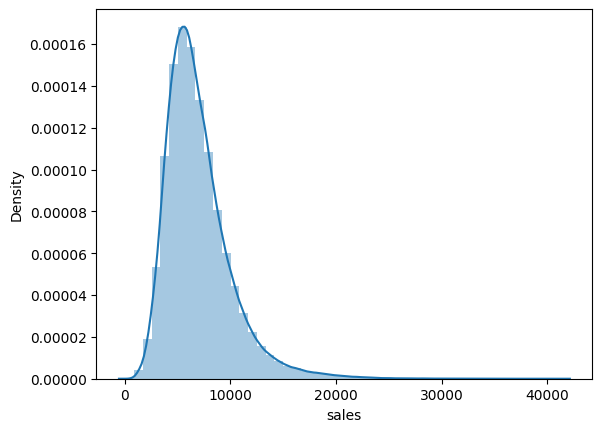

In [33]:
sns.distplot(df4['sales']);

### 3.1.2 Numerical Variable

<Figure size 2100x600 with 0 Axes>

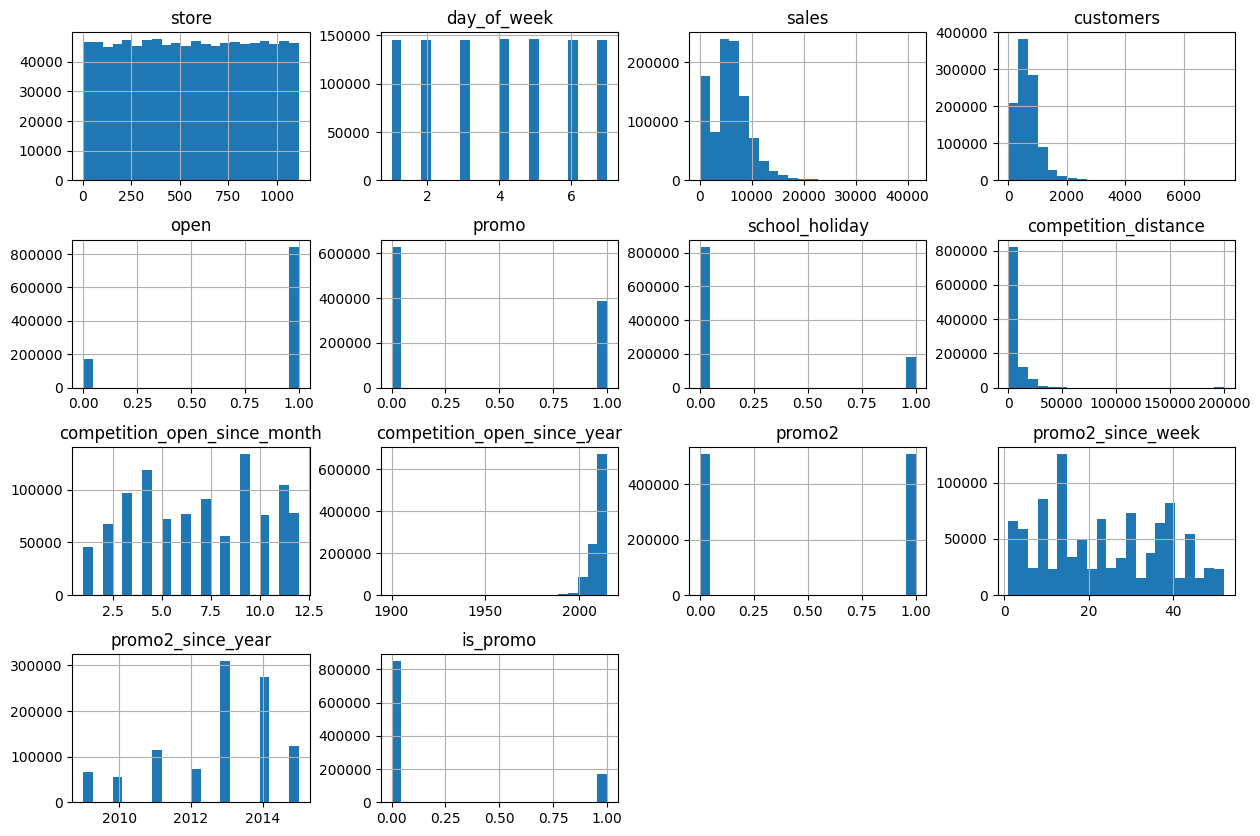

In [71]:
plt.figure(figsize=(21, 6))
num_attributes.hist(bins=22, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()


### 3.1.3 Categorical Variable

In [60]:
df4.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='object')

In [62]:
df4['assortment'].drop_duplicates()

0         basic
3      extended
258       extra
Name: assortment, dtype: object

In [63]:
df4['assortment'].unique()

array(['basic', 'extended', 'extra'], dtype=object)

C:\Users\ALL RH\AppData\Local\Temp\ipykernel_7252\1267955972.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=a, x='state_holiday', palette='Set2');
C:\Users\ALL RH\AppData\Local\Temp\ipykernel_7252\1267955972.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df4[df4['state_holiday'] == 'public holiday'] ['sales'], label='public holiday', shade=True )
C:\Users\ALL RH\AppData\Local\Temp\ipykernel_7252\1267955972.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df4[df4['state_holiday'] == 'Easter holiday'] ['sales'], label='Easter holiday', shade=True )
C:\Users\ALL RH\AppData\Loc

<Axes: xlabel='sales', ylabel='Density'>

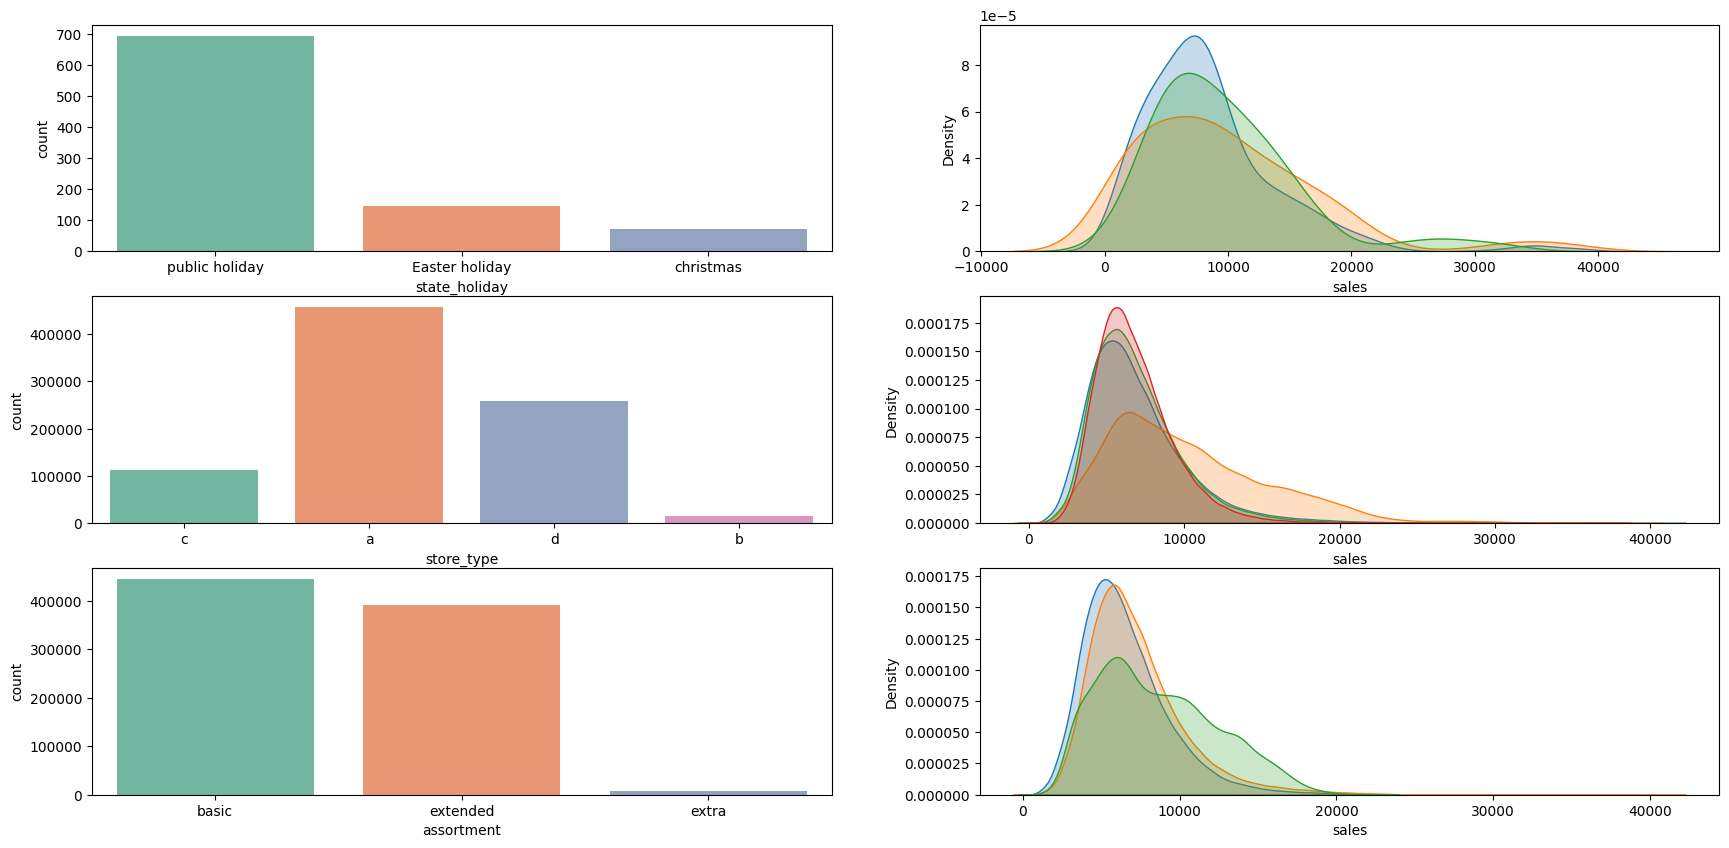

In [69]:
plt.figure(figsize=(21, 10))

# state_holiday
plt.subplot(3,2,1)
a = df4[df4['state_holiday'] != 'relugar_day']
sns.countplot(data=a, x='state_holiday', palette='Set2');

plt.subplot(3,2,2)
sns.kdeplot(df4[df4['state_holiday'] == 'public holiday'] ['sales'], label='public holiday', shade=True )
sns.kdeplot(df4[df4['state_holiday'] == 'Easter holiday'] ['sales'], label='Easter holiday', shade=True )
sns.kdeplot(df4[df4['state_holiday'] == 'christmas'] ['sales'], label='christmas', shade=True )

# store type
plt.subplot(3,2,3)
sns.countplot(data=df4, x='store_type', palette='Set2');

plt.subplot(3,2,4)
sns.kdeplot(df4[df4['store_type'] == 'a'] ['sales'], label='a', shade=True )
sns.kdeplot(df4[df4['store_type'] == 'b'] ['sales'], label='b', shade=True )
sns.kdeplot(df4[df4['store_type'] == 'c'] ['sales'], label='c', shade=True )
sns.kdeplot(df4[df4['store_type'] == 'd'] ['sales'], label='d', shade=True )

# assortment
plt.subplot(3,2,5)
sns.countplot(data=df4, x='assortment', palette='Set2');

plt.subplot(3,2,6)
sns.kdeplot(df4[df4['assortment'] == 'basic'] ['sales'], label='basic', shade=True )
sns.kdeplot(df4[df4['assortment'] == 'extended'] ['sales'], label='extended', shade=True )
sns.kdeplot(df4[df4['assortment'] == 'extra'] ['sales'], label='extra', shade=True )

## 3.2. Bivariate Analysis

## 3.3. Multivariate Analysis